In [ ]:
import os
import geopandas as gpd
import rioxarray as rxr
from geocube.api.core import make_geocube
from xrspatial import zonal_stats

def generate_multi_raster_zonal_stats(raster_paths, shapefile_path, output_dir, zone_column):
    """
    Calculates zonal statistics for multiple rasters and saves them to CSV.
    """
    # 1. Load the shapefile
    gdf = gpd.read_file(shapefile_path)
    
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for raster_path in raster_paths:
        # 2. Load raster using rioxarray
        raster = rxr.open_rasterio(raster_path, masked=True).sel(band=1)
        
        # 3. Rasterize the shapefile to match raster dimensions
        vector_raster = make_geocube(
            vector_data=gdf,
            measurements=[zone_column],
            like=raster
        )
        
        # 4. Calculate Zonal Statistics
        # Computes count, sum, mean, std, min, and max by default
        stats = zonal_stats(
            zones=vector_raster[zone_column], 
            values=raster
        )
        
        # 5. Save output
        raster_name = os.path.splitext(os.path.basename(raster_path))[0]
        output_file = os.path.join(output_dir, f"{raster_name}_stats.csv")
        stats.to_csv(output_file, index=False)
        print(f"Saved: {output_file}")

# Example Usage
rasters = ["sv_lst_20251222.tif", "sv_lst_20251214.tif", "sv_lst_20251128.tif","sv_lst_20251120.tif","sv_lst_20250901.tif", "sv_lst_20250731.tif", "sv_lst_20250723.tif", "sv_lst_20250715.tif", "sv_lst_20250629.tif", "sv_lst_20250512.tif", "sv_lst_20250410.tif", "sv_lst_20250301.tif", "sv_lst_20250221.tif", "sv_lst_20250205.tif", "sv_lst_20250128.tif", "sv_lst_20250104.tif"]
generate_multi_raster_zonal_stats(rasters, "sv_zone.shp", "output_folder", "gridcode")


Saved: output_folder\sv_lst_20251222_stats.csv
Saved: output_folder\sv_lst_20251214_stats.csv
Saved: output_folder\sv_lst_20251128_stats.csv
Saved: output_folder\sv_lst_20251120_stats.csv
Saved: output_folder\sv_lst_20250901_stats.csv
Saved: output_folder\sv_lst_20250731_stats.csv
Saved: output_folder\sv_lst_20250723_stats.csv
Saved: output_folder\sv_lst_20250715_stats.csv
Saved: output_folder\sv_lst_20250629_stats.csv
Saved: output_folder\sv_lst_20250512_stats.csv
Saved: output_folder\sv_lst_20250410_stats.csv
Saved: output_folder\sv_lst_20250301_stats.csv
Saved: output_folder\sv_lst_20250221_stats.csv
Saved: output_folder\sv_lst_20250205_stats.csv
Saved: output_folder\sv_lst_20250128_stats.csv
Saved: output_folder\sv_lst_20250104_stats.csv


In [ ]:
import pandas as pd
import glob
import os

def combine_csv_files(input_folder, output_filename):
    """"
    Concatenates all individual tables into a single table.

    """
    # 1. Create a list of all CSV files in the folder
    # Uses glob to find every file ending in .csv
    path = os.path.join(input_folder, "*.csv")
    all_files = glob.glob(path)

    # 2. Read each CSV into a list of DataFrames
    df_list = [pd.read_csv(f) for f in all_files]

    if not df_list:
        print("No CSV files found in the specified folder.")
        return

    # 3. Concatenate all DataFrames into one
    combined_df = pd.concat(df_list, ignore_index=True)

    # 4. Save the result to a new CSV file
    # index=False prevents pandas from adding an extra column for the index
    combined_df.to_csv(output_filename, index=False)
    print(f"Successfully combined {len(all_files)} files into '{output_filename}'.")

# Example Usage:
combine_csv_files("output_folder", "final_merged_sv_lst_2025.csv")


Successfully combined 16 files into 'final_merged_sv_lst_2025.csv'.


In [ ]:
import pandas as pd
from scipy import stats

def perform_ttest(csv_path, col1, col2, dropna=True):
    """
    Performs independent t-test.
    """
    # 1. Read CSV
    df = pd.read_csv(csv_path)
    
    # 2. Extract data, dropping NA if requested
    data1 = df[col1]
    data2 = df[col2]
    if dropna:
        data1 = data1.dropna()
        data2 = data2.dropna()
    
    # 3. Perform T-test
    t_stat, p_val = stats.ttest_ind(data1, data2)
    
    # 4. Print Results
    print(f"--- T-Test Results ({col1} vs {col2}) ---")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_val:.4f}")
    
    # Interpretation
    if p_val < 0.05:
        print("Result: Statistically significant (reject H0)")
    else:
        print("Result: Not statistically significant (fail to reject H0)")

# Example Usage (replace 'data.csv' and column names)
perform_ttest('final_merged_sv_lst_2025_.csv', 'z1_mean', 'z2_mean')

perform_ttest('final_merged_sv_lst_2025_.csv', 'z1_max', 'z2_max')

perform_ttest('final_merged_sv_lst_2025_.csv', 'z1_min', 'z2_min')


--- T-Test Results (z1_mean vs z2_mean) ---
T-statistic: 5.6328
P-value: 0.0000
Result: Statistically significant (reject H0)
--- T-Test Results (z1_max vs z2_max) ---
T-statistic: 2.1776
P-value: 0.0333
Result: Statistically significant (reject H0)
--- T-Test Results (z1_min vs z2_min) ---
T-statistic: 2.5116
P-value: 0.0146
Result: Statistically significant (reject H0)


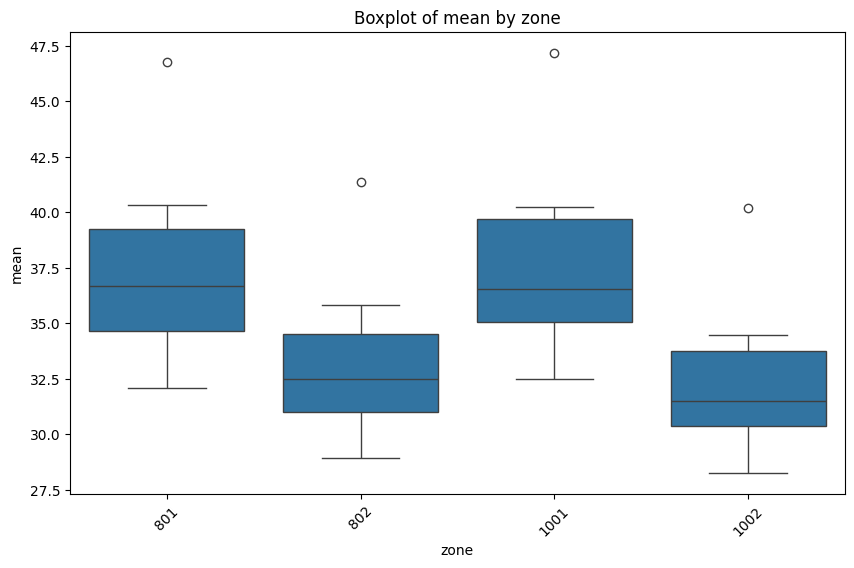

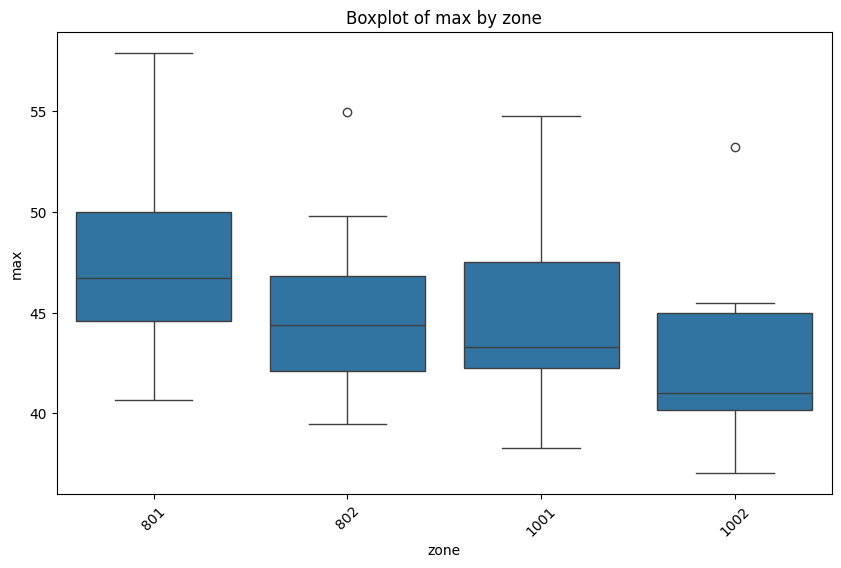

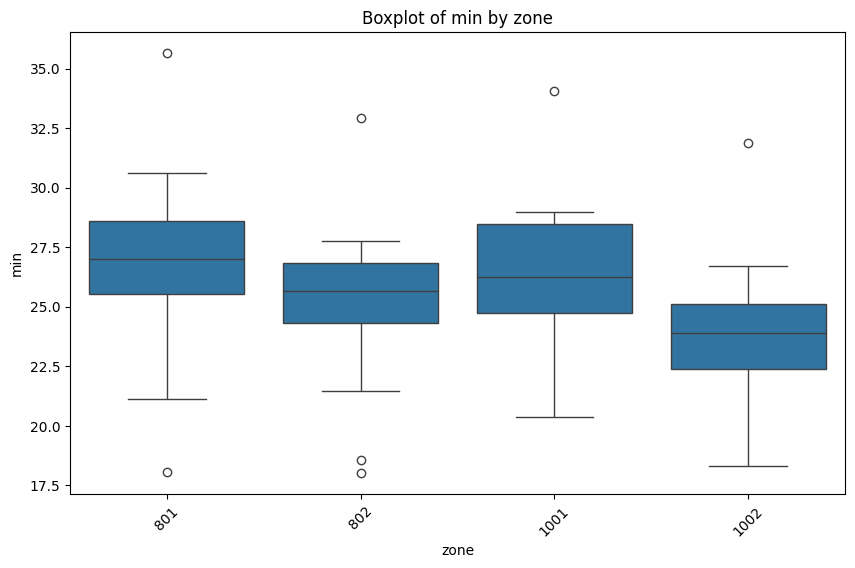

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def create_boxplot(csv_path, x_col, y_col):
    """Loads CSV and creates a Seaborn boxplot."""
    try:
        # Load the dataset
        df = pd.read_csv(csv_path)
        
        # Create plot
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=x_col, y=y_col)
        
        # Add labels and title
        plt.title(f'Boxplot of {y_col} by {x_col}')
        plt.xticks(rotation=45)
        
        # Display plot
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

# Usage Example:
create_boxplot('final_merged_sv_lst_2025.csv', 'zone', 'mean')
create_boxplot('final_merged_sv_lst_2025.csv', 'zone', 'max')
create_boxplot('final_merged_sv_lst_2025.csv', 'zone', 'min')

# Using built-in tips dataset for demonstration

plt.show()


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the CSV file
df = pd.read_csv('final_merged_sv_lst_2025_v2.csv')
df.head()


,year,month,day,date,zone,mean,max,min,sum,std,var,count,majority
0,2025,1,4,202514,801,32.068691,40.690849,21.109015,183689.4688,2.848029,8.111269,5728,32.576469
1,2025,1,28,2025128,801,35.170616,44.488270,27.169163,201457.2813,2.434583,5.927197,5728,37.799206
2,2025,2,5,202525,801,35.192730,44.744621,26.830780,201583.9531,2.545919,6.481704,5728,33.246403
3,2025,2,21,2025221,801,36.358223,46.009289,28.081776,208259.9063,2.474470,6.123001,5728,37.430061
4,2025,3,1,202531,801,39.556797,51.464451,30.515406,226581.3438,3.025963,9.156452,5728,39.603920


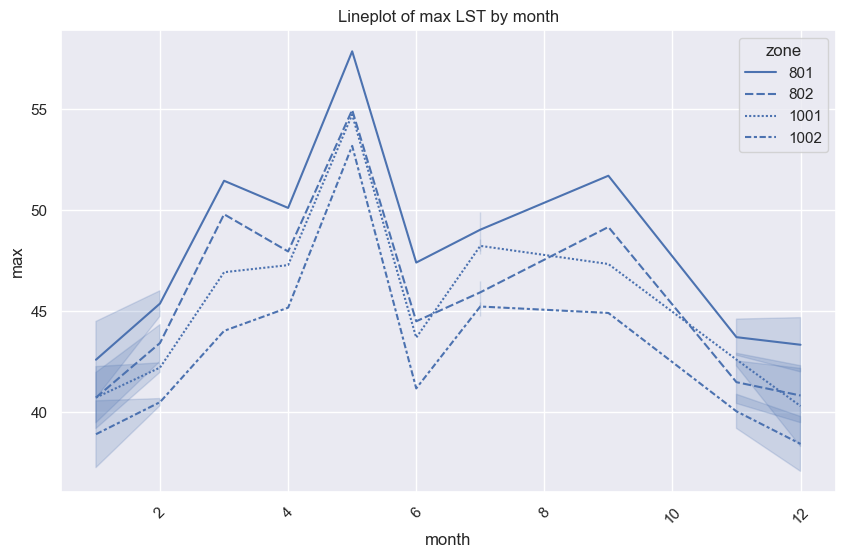

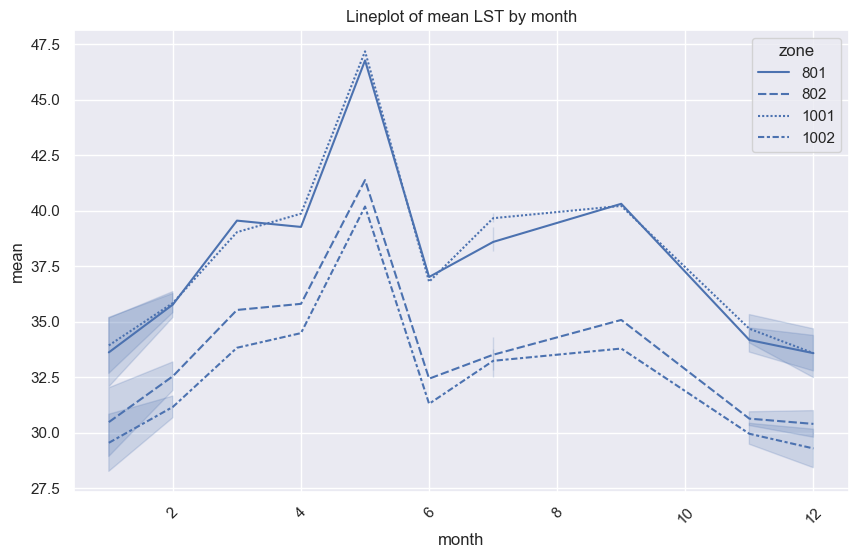

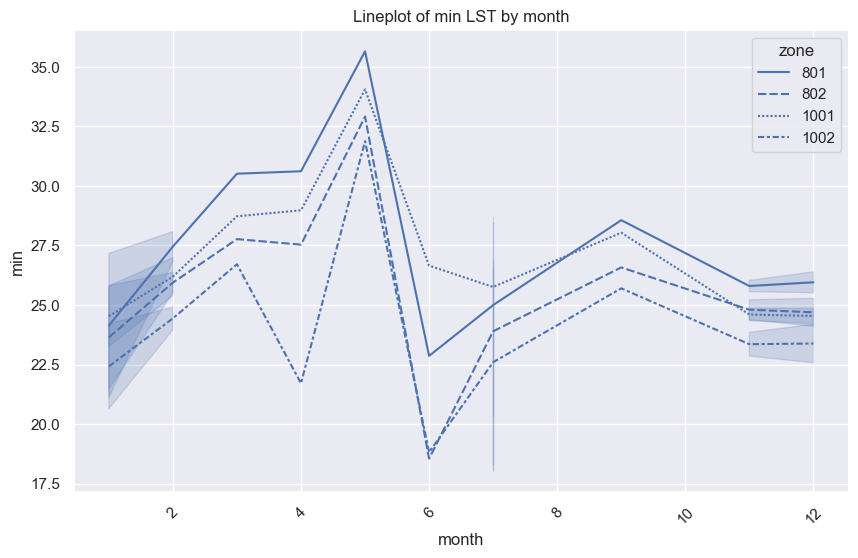

In [5]:
import pandas as pd
import seaborn.objects as so
import seaborn as sns
import matplotlib.pyplot as plt

def create_lineplot(x_col, y_col, z_col, csv_path):
    """Loads CSV and creates a Seaborn boxplot."""
    try:
        # Load the dataset
        df = pd.read_csv(csv_path)
        
        # Create plot
        plt.figure(figsize=(10, 6))
        sns.set_theme(style="darkgrid")
        sns.lineplot(x=x_col, y=y_col, style=z_col, data=df,)
        
        # Add labels and title
        plt.title(f'Lineplot of {y_col} LST by {x_col}')
        plt.xticks(rotation=45)
        
        # Display plot
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

# Usage Example:
create_lineplot("month", "max", "zone", 'final_merged_sv_lst_2025_v2.csv')
create_lineplot("month", "mean", "zone", 'final_merged_sv_lst_2025_v2.csv')
create_lineplot("month", "min", "zone", 'final_merged_sv_lst_2025_v2.csv')

# Using built-in tips dataset for demonstration

plt.show()

<Axes: xlabel='month', ylabel='max'>

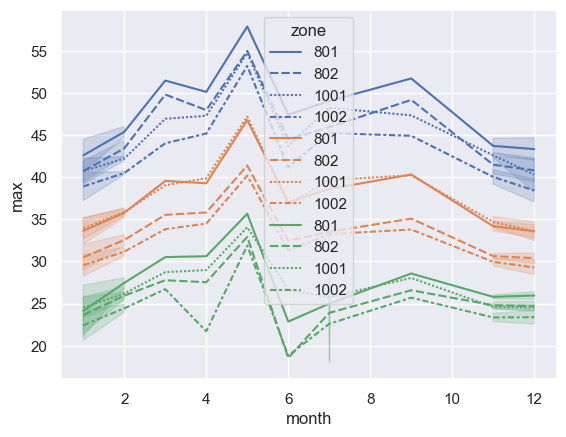

In [27]:
sns.set_theme(style="darkgrid")

# Plot the responses for different events and regions
sns.lineplot(x="month", y="max", style="zone", data=df)
sns.lineplot(x="month", y="mean", style="zone", data=df)
sns.lineplot(x="month", y="min", style="zone", data=df)

<Axes: xlabel='month', ylabel='std'>

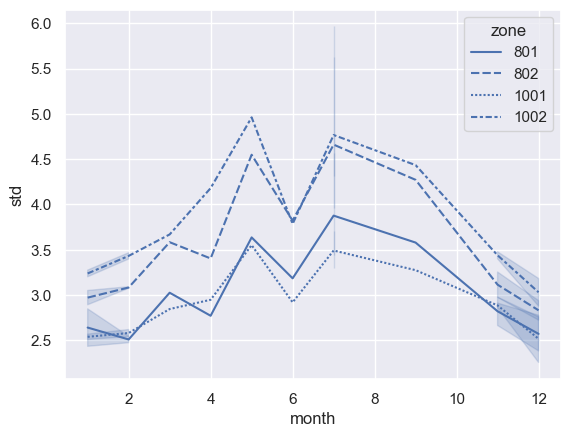

In [19]:
sns.lineplot(x="month", y="std", style="zone",
             data=df)

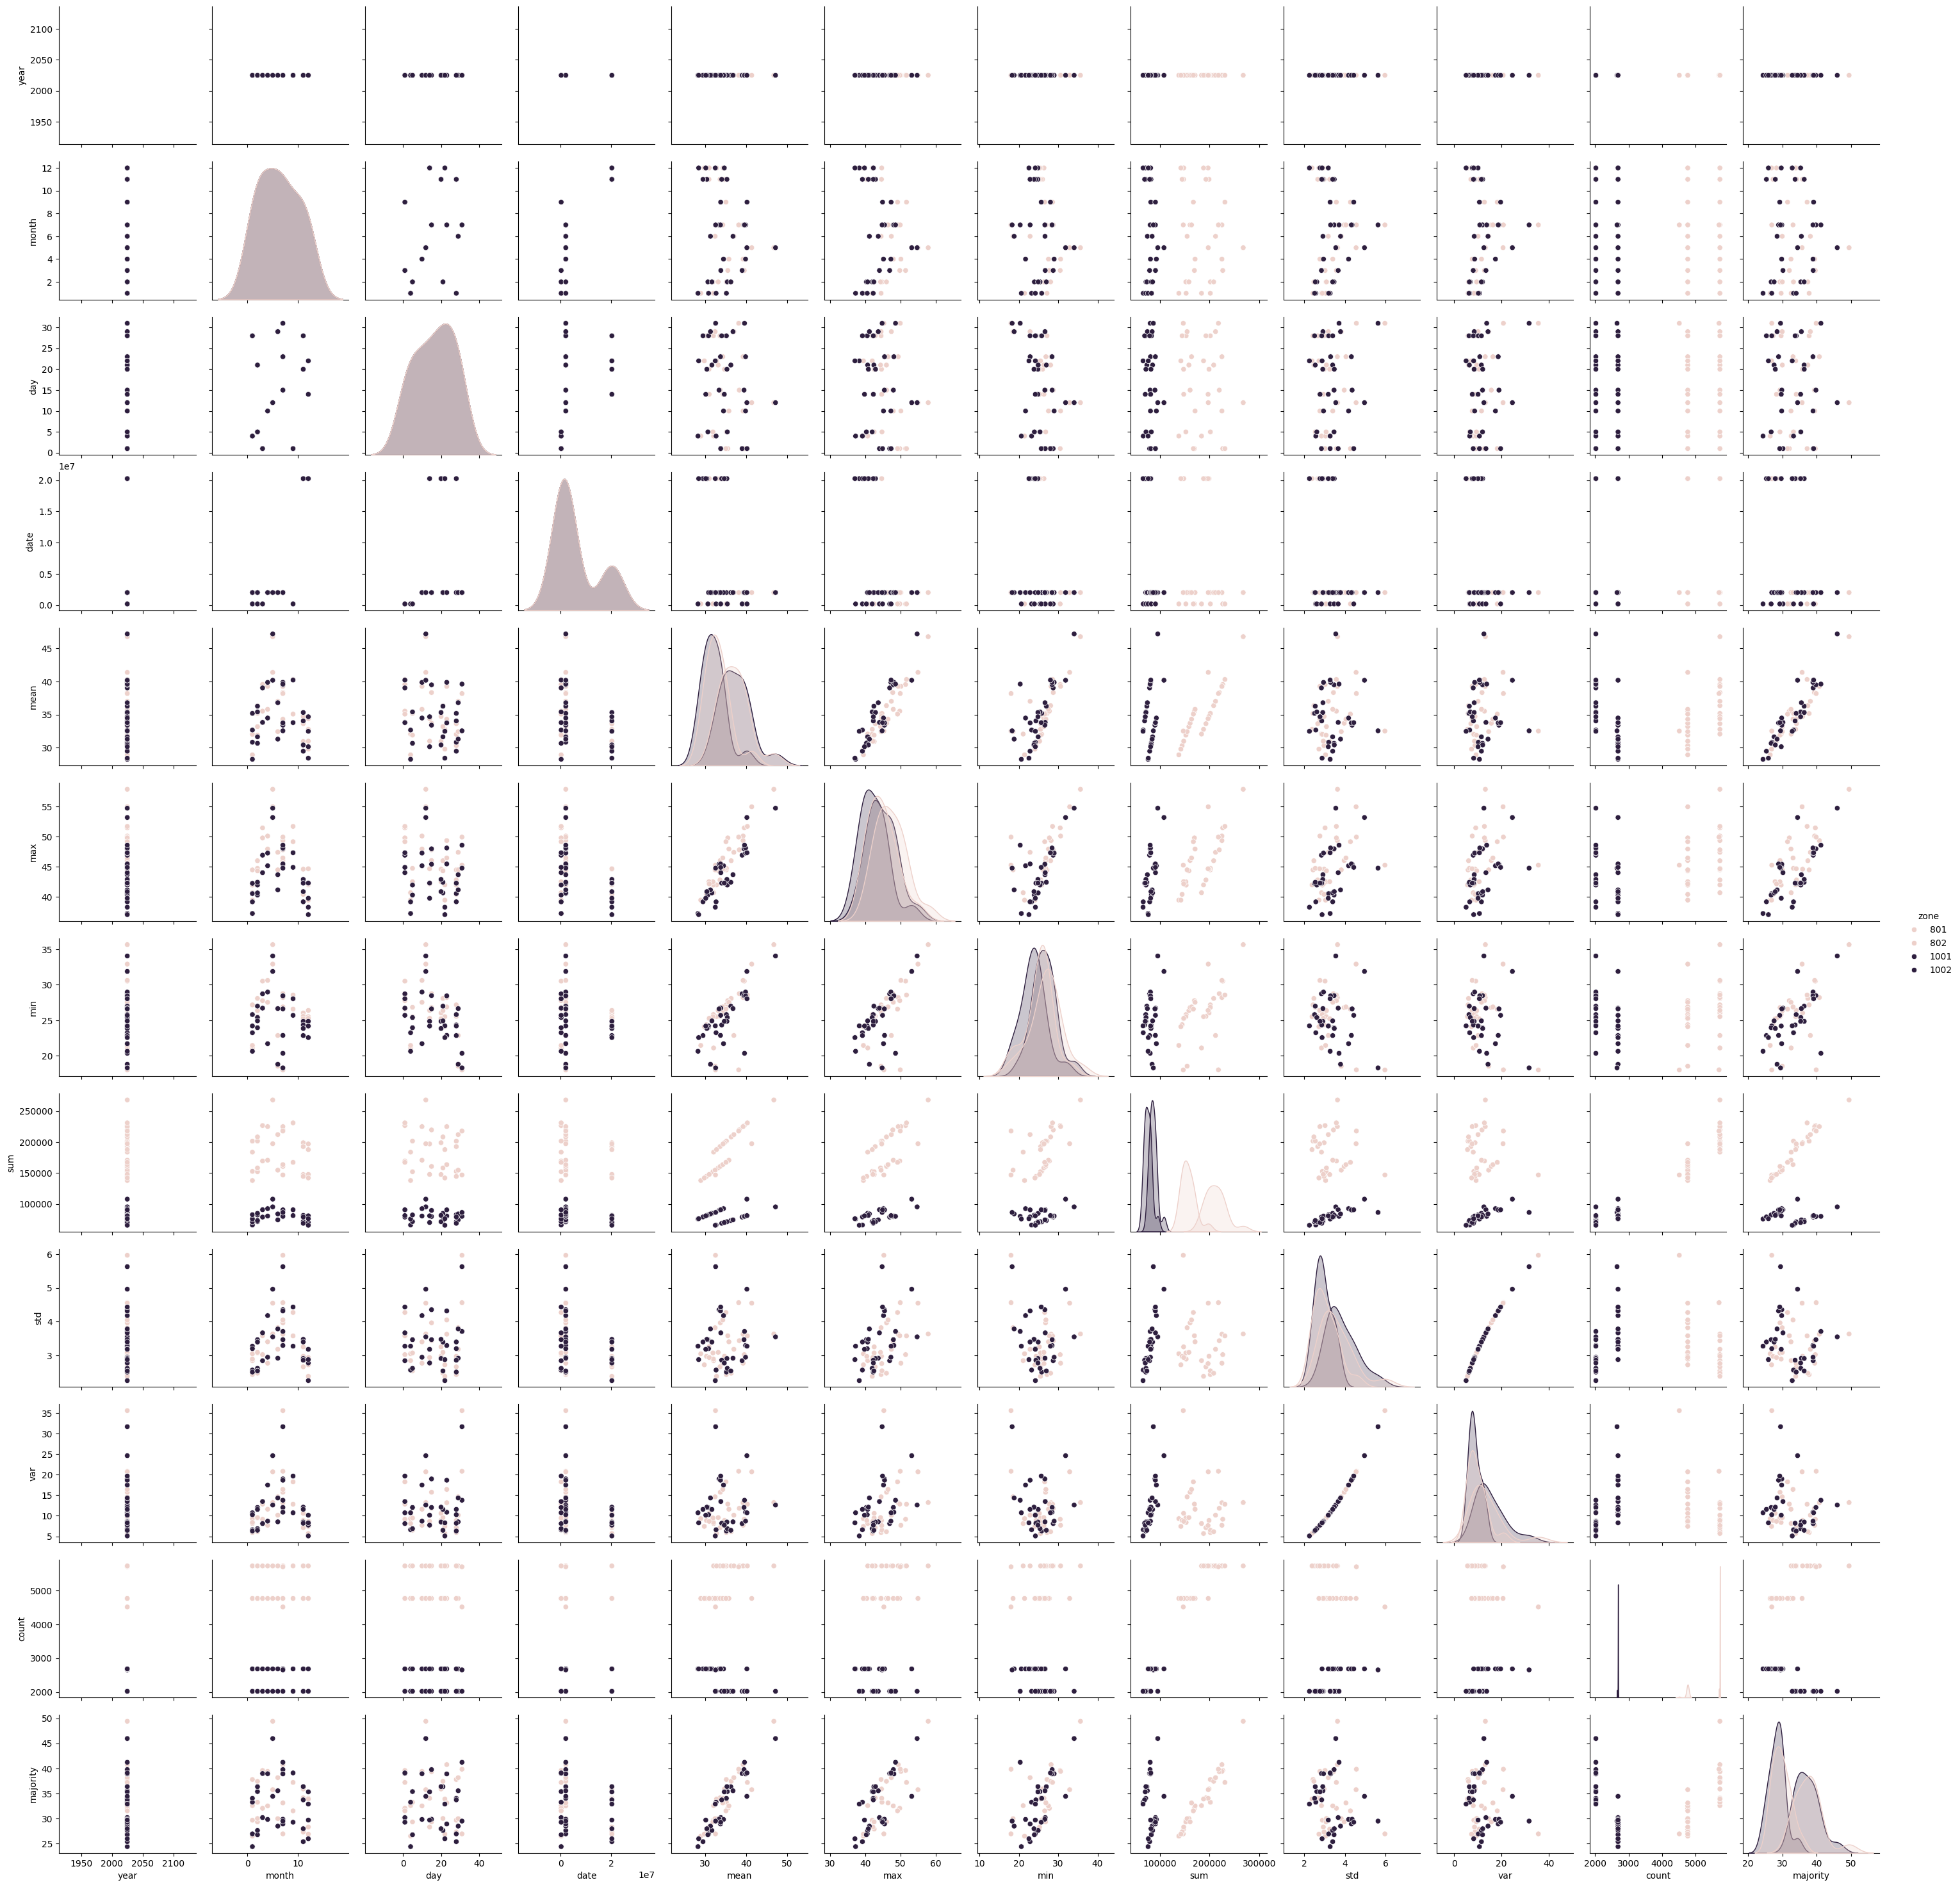

In [5]:

sns.pairplot(df, hue="zone")

In [ ]:
import rioxarray
import xarray as xr
import glob
import os
import numpy as np

def calculate_multi_raster_stats(input_folder, output_path, statistic='mean'):
    """
    Calculates cell statistics (mean, max, sum) for all rasters (LST) in a folder.
    """
    # 1. Get list of all tif files
    search_path = os.path.join(input_folder, "*.tif")
    raster_files = glob.glob(search_path)
    
    if not raster_files:
        print("No .tif files found in folder.")
        return

    # 2. Open all rasters and stack them along a new dimension ('time' or 'band')
    # Using open_rasterio ensures spatial metadata is preserved
    raster_da_list = [rioxarray.open_rasterio(r) for r in raster_files]
    stacked = xr.concat(raster_da_list, dim='band')

    # 3. Calculate statistics across the stacked dimension
    if statistic == 'mean':
        result = stacked.mean(dim='band')
    elif statistic == 'max':
        result = stacked.max(dim='band')
    elif statistic == 'sum':
        result = stacked.sum(dim='band')
    else:
        raise ValueError("Statistic not supported. Use 'mean', 'max', or 'sum'.")

    # 4. Save the resulting raster
    result.rio.to_raster(output_path)
    print(f"Cell statistics ({statistic}) saved to: {output_path}")

# Example Usage
input_dir = "C:/Users/be81h/Documents/408_cel_/research_prj"
output_file = "C:/Users/be81h/Documents/408_cel_/research_prj/output_file/cell_mean.tif"
# Make sure to create the directories if they don't exist
calculate_multi_raster_stats(input_dir, output_file, statistic='mean')


Cell statistics (mean) saved to: C:/Users/be81h/Documents/408_cel_/research_prj/output_file/cell_mean.tif


c:\Users\be81h\Documents\408_cel_\exercise_4_\.pixi\envs\default\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


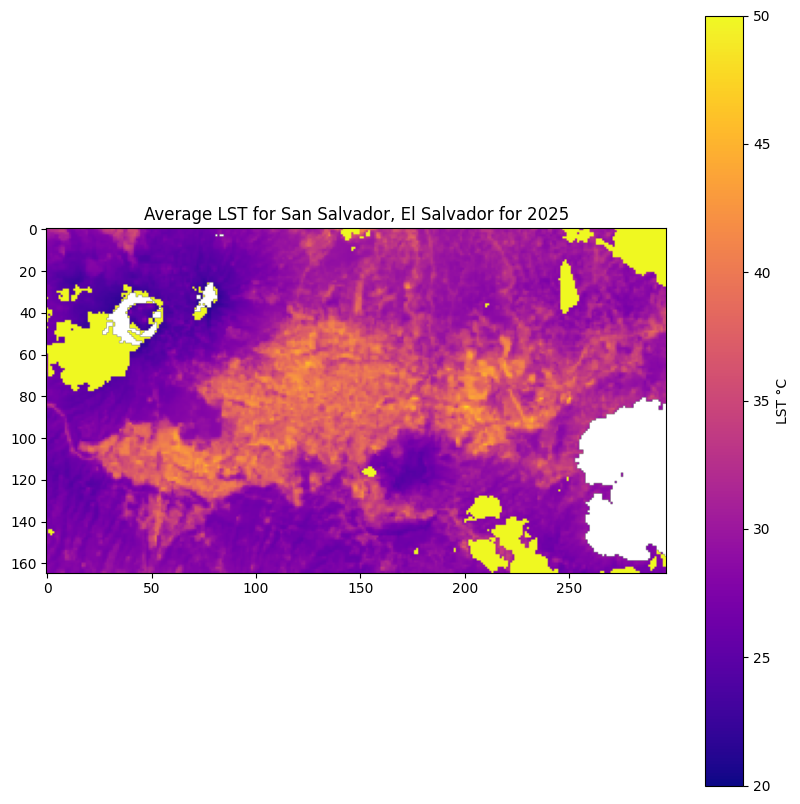

In [20]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

"""
    Plot the average LST results for San Salvador, El Salvador for 2025.
"""

# Open the raster file
raster = 'C:/Users/be81h/Documents/408_cel_/research_prj/output_file/cell_mean.tif'

# Open and Plot
with rasterio.open(raster) as src:
    # Read the first band
    raster_data = src.read(1)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot with values constrained between 20 and 50
    img = ax.imshow(raster_data, cmap='plasma', vmin=20, vmax=50)
    
    # Add colorbar to show scale
    fig.colorbar(img, ax=ax, label='LST °C')
    
    ax.set_title('Average LST for San Salvador, El Salvador for 2025')
    plt.show()